AAF project by Marsel Miller

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from scipy.optimize import minimize

In [9]:
df = pd.read_excel('HW3_dataset.xlsx')

df = df.rename(columns={'Unnamed: 0': 'Date'})

print("Shape:", df.shape)

print("\nColumns:")
for col in df.columns:
    print(col)

print("\nFirst 5 rows:")
print(df.head())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isna().sum().sort_values(ascending=False))

Shape: (474, 31)

Columns:
Date
US_Earnings_yield
US_DIV_Yield
Equity Volatility
TED
Financial Conditions Index
Credit Subindex
Leverage Subindex
Risk Subindex
Non Financial Leverage Subindex
Credit Spread
Credit Spread - change
Inflation
Expected Inflation
IP YoY
unemployement
yields 10Y
Term Spread
Term Spread - change
DXY
CAPE
Excess CAPE Yield
Oil - change
Equity
Bonds
Credits
Comm
Gold
HY
RF
Inflation change

First 5 rows:
        Date  US_Earnings_yield  US_DIV_Yield  Equity Volatility   TED  \
0 1983-08-31             0.0768        0.0417           0.158163  0.29   
1 1983-09-30             0.0804        0.0430           0.111111  0.22   
2 1983-10-31             0.0795        0.0419           0.101115  0.45   
3 1983-11-30             0.0808        0.0419           0.105561  0.84   
4 1983-12-31             0.0835        0.0427           0.089781  0.58   

   Financial Conditions Index  Credit Subindex  Leverage Subindex  \
0                    -0.10678          0.18507        

Dataset contains both macroeconomic predictors and asset return series required for the portfolio allocation, additionally, it helps identify potential data quality issues that should be addressed before implementing the Random Forest portfolio allocation algorithm


In [10]:
# Asset returns
asset_cols = [
    'Equity',
    'Bonds',
    'Credits',
    'Comm',
    'Gold',
    'HY'
]

rf_col = 'RF'

# State variables
feature_cols = [
    col for col in df.columns
    if col not in asset_cols + [rf_col, 'Date']
]

print("Number of observations:", len(df))
print()

print("Number of state variables:", len(feature_cols))
print()

print("State variables:")
print(feature_cols)

print()
print("Assets:")
print(asset_cols)

Number of observations: 474

Number of state variables: 23

State variables:
['US_Earnings_yield', 'US_DIV_Yield', 'Equity Volatility', 'TED', 'Financial Conditions Index', 'Credit Subindex', 'Leverage Subindex', 'Risk Subindex', 'Non Financial Leverage Subindex', 'Credit Spread', 'Credit Spread - change', 'Inflation', 'Expected Inflation', 'IP YoY', 'unemployement', 'yields 10Y', 'Term Spread', 'Term Spread - change', 'DXY', 'CAPE', 'Excess CAPE Yield', 'Oil - change', 'Inflation change']

Assets:
['Equity', 'Bonds', 'Credits', 'Comm', 'Gold', 'HY']


The variables in the dataset were separated into state variables and asset returns. A total of 23 state variables representing valuation metrics, macroeconomic indicators, market conditions, and risk measures - these variables will be used by the "random forest" algorithm to identify different market environments

The dataset also contains six risky assets - Equity, Bonds, Credits, Commodities, Gold, and High Yield bonds: these assets form the investment universe for the portfolio allocation exercise


In [11]:
asset_returns = df[asset_cols]

print(asset_returns.describe().T)

         count      mean       std       min       25%       50%       75%  \
Equity   474.0  0.009638  0.045116 -0.226400 -0.016550  0.014350  0.038725   
Bonds    474.0  0.006536  0.029336 -0.094242 -0.009770  0.004894  0.022999   
Credits  474.0  0.005979  0.016773 -0.074740 -0.002623  0.006269  0.015418   
Comm     474.0  0.005072  0.059350 -0.294254 -0.024558  0.006519  0.042928   
Gold     474.0  0.004150  0.043605 -0.168896 -0.023027 -0.001022  0.030087   
HY       474.0  0.006944  0.024261 -0.159068 -0.001636  0.008641  0.018050   

              max  
Equity   0.136500  
Bonds    0.130963  
Credits  0.063972  
Comm     0.229400  
Gold     0.168453  
HY       0.121047  


The summary statistics indicate noticeable differences in risk and return characteristics across asset classes. Equity generated the highest average monthly return (0.96%), while Commodities exhibited the highest volatility among all assets. Bonds, Credits, and High Yield bonds produced relatively stable returns with lower volatility compared to Equity and Commodities.

Several asset classes experienced substantial drawdowns during the sample period, particularly Equities, Commodities, and Gold, reflecting periods of market stress. Overall, the descriptive statistics confirm that the investment universe contains assets with diverse risk-return profiles, creating potential benefits for portfolio diversification and active asset allocation


         Equity  Bonds  Credits   Comm   Gold     HY
Equity    1.000  0.032    0.343  0.229 -0.026  0.640
Bonds     0.032  1.000    0.768 -0.141  0.107  0.121
Credits   0.343  0.768    1.000  0.079  0.162  0.570
Comm      0.229 -0.141    0.079  1.000  0.207  0.231
Gold     -0.026  0.107    0.162  0.207  1.000  0.068
HY        0.640  0.121    0.570  0.231  0.068  1.000


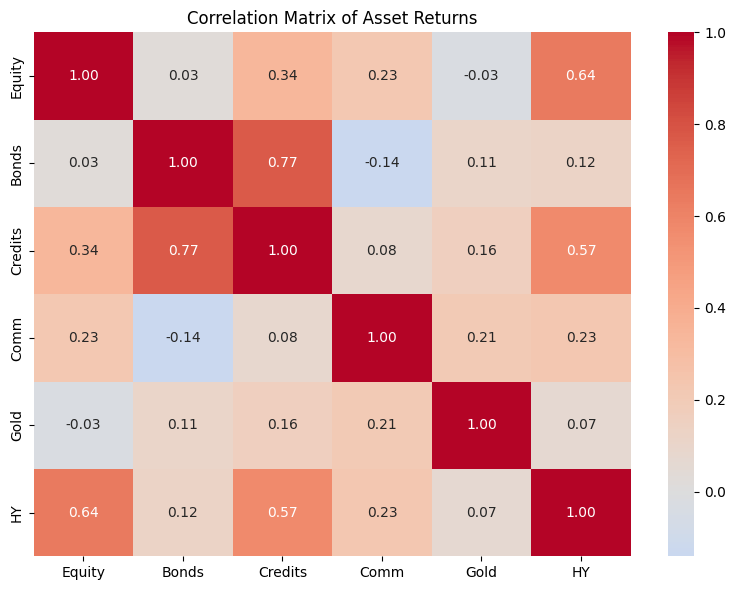

In [12]:
#сorrelation matrix of asset returns
corr_matrix = asset_returns.corr()

print(corr_matrix.round(3))

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    center=0,
    fmt='.2f'
)

plt.title('Correlation Matrix of Asset Returns')
plt.tight_layout()
plt.show()

The correlation matrix reveals meaningful diversification opportunities across the asset universe 
 1) Bonds and Credits exhibit the strongest positive correlation, reflecting their common exposure to fixed-income market conditions
 2) High Yield bonds are strongly correlated with Equities, indicating that they share sensitivity to changes in economic and financial conditions.
 3) Gold displays very low correlations with all other asset classes and a slightly negative correlation with Equities - thus gold may provide diversification benefits despite its relatively modest average return
 4) Commodities also exhibit low correlations with most assets and a negative correlation with Bonds, further supporting their potential role as portfolio diversifiers



In [13]:
# Summary statistics for state variables

state_stats = df[feature_cols].describe().T

print(
    state_stats[
        ['mean', 'std', 'min', '25%', '50%', '75%', 'max']
    ].round(3)
)

                                   mean    std    min     25%     50%     75%  \
US_Earnings_yield                 0.051  0.017  0.008   0.041   0.050   0.060   
US_DIV_Yield                      0.023  0.008  0.011   0.018   0.020   0.028   
Equity Volatility                 0.152  0.096  0.047   0.095   0.125   0.178   
TED                               0.278  0.364 -0.640   0.040   0.130   0.470   
Financial Conditions Index       -0.337  0.513 -1.110  -0.647  -0.504  -0.175   
Credit Subindex                   0.011  0.429 -0.715  -0.242  -0.104   0.143   
Leverage Subindex                -0.006  0.790 -1.720  -0.420  -0.109   0.264   
Risk Subindex                    -0.350  0.526 -1.149  -0.689  -0.525  -0.153   
Non Financial Leverage Subindex  -0.022  1.067 -2.011  -0.863  -0.044   0.702   
Credit Spread                     0.018  0.006  0.011   0.015   0.018   0.021   
Credit Spread - change           -0.000  0.002 -0.009  -0.001  -0.000   0.001   
Inflation                   

The summary statistics indicate substantial variation across the state variables used to characterize market conditions: several predictors, including Equity Volatility, TED spread, Credit Spread, Unemployment, and CAPE, exhibit wide ranges over the sample period, reflecting the presence of different economic and financial states

Many variables capture episodes of market stress and economic uncertainty, while others describe valuation conditions and macroeconomic fundamentals. This variation is important for the Asset Allocation Forest (AAF) framework because the tree-based algorithm relies on these predictors to identify distinct market environments and allocate assets accordingly


In [14]:
print(df['Date'].min())
print(df['Date'].max())

1983-08-31 00:00:00
2023-01-31 00:00:00


In [15]:
for years in [10, 15, 20]:
    
    n_months = years * 12
    
    print(
        f"{years} years:",
        len(df) - n_months,
        "out-of-sample observations"
    )

10 years: 354 out-of-sample observations
15 years: 294 out-of-sample observations
20 years: 234 out-of-sample observations


15 year training period was chosen as a compromise between estimation accuracy and the length of the evaluation period.

A longer estimation window provides more reliable estimates of expected returns and covariances, which are required for portfolio optimization within the Asset Allocation Forest framework, at the same time, the selected window preserves a sufficiently large number of OOS observations for performance evaluation


In [16]:
initial_window = 15 * 12

train = df.iloc[:initial_window]
test = df.iloc[initial_window:]

print("Train observations:", len(train))
print("Test observations:", len(test))

print()
print("Train period:")
print(train['Date'].min(), "to", train['Date'].max())

print()
print("Test period:")
print(test['Date'].min(), "to", test['Date'].max())

Train observations: 180
Test observations: 294

Train period:
1983-08-31 00:00:00 to 1998-07-31 00:00:00

Test period:
1998-08-31 00:00:00 to 2023-01-31 00:00:00


In [17]:
X = df[feature_cols]

R = df[asset_cols]

print("Predictor matrix shape:", X.shape)
print("Return matrix shape:", R.shape)

print()
print("Number of predictors:", X.shape[1])
print("Number of assets:", R.shape[1])

Predictor matrix shape: (474, 23)
Return matrix shape: (474, 6)

Number of predictors: 23
Number of assets: 6


The dataset was organized into two main components. The predictor matrix contains 23 state variables describing macroeconomic conditions, market valuations, financial conditions, and risk indicators. The return matrix contains monthly returns for six asset classes: Equities, Bonds, Credits, Commodities, Gold, and High Yield bonds.

This structure follows the Asset Allocation Forest framework, where state variables are used to identify market regimes, while asset returns are used to estimate portfolio allocations within each node of the tree


In [18]:
from scipy.optimize import minimize

def max_sharpe_portfolio(returns, rf):

    mu = returns.mean().values
    cov = returns.cov().values

    rf_mean = rf.mean()

    n_assets = len(mu)

    def neg_sharpe(weights):

        port_return = np.dot(weights, mu)

        port_vol = np.sqrt(
            weights.T @ cov @ weights
        )

        sharpe = (
            port_return - rf_mean
        ) / port_vol

        return -sharpe

    constraints = (
        {'type': 'eq',
         'fun': lambda w: np.sum(w) - 1}
    )

    bounds = tuple(
        (0, 1) for _ in range(n_assets)
    )

    w0 = np.ones(n_assets) / n_assets

    result = minimize(
        neg_sharpe,
        w0,
        method='SLSQP',
        bounds=bounds,
        constraints=constraints
    )

    return result.x

The portfolio optimization procedure was tested on the initial training sample. The resulting allocation is concentrated primarily in Credits and High Yield bonds, while Equities and Gold receive relatively small weights and Bonds receive virtually no allocation

This outcome reflects the historical risk-return characteristics of the assets during the estimation period. Assets with more attractive risk-adjusted performance receive larger portfolio weights, while assets that offer limited diversification benefits or lower risk-adjusted returns receive smaller allocations


In [19]:
weights = max_sharpe_portfolio(
    train[asset_cols],
    train['RF']
)

weights_df = pd.DataFrame({
    'Asset': asset_cols,
    'Weight (%)': (weights * 100).round(2)
})

print(weights_df)

print()
print("Sum of weights:", round(weights.sum(), 4))

     Asset  Weight (%)
0   Equity        8.23
1    Bonds        0.00
2  Credits       45.52
3     Comm       11.41
4     Gold        0.00
5       HY       34.84

Sum of weights: 1.0


The portfolio optimization procedure was tested on the initial training sample. The resulting allocation is concentrated primarily in Credits and High Yield bonds, while Equities receive relatively small weight and Bonds\Gold receive no allocation

This outcome reflects the historical risk-return characteristics of the assets during the estimation period. Assets with more attractive risk-adjusted performance receive larger portfolio weights, while assets that offer limited diversification benefits or lower risk-adjusted returns receive smaller allocations


In [20]:
mu = train[asset_cols].mean().values
cov = train[asset_cols].cov().values
rf_mean = train['RF'].mean()

port_return = np.dot(weights, mu)

port_vol = np.sqrt(
    weights.T @ cov @ weights
)

sharpe = (
    port_return - rf_mean
) / port_vol

stats = pd.DataFrame({
    'Metric': [
        'Expected Return',
        'Volatility',
        'Risk-Free Rate',
        'Sharpe Ratio'
    ],
    'Value': [
        port_return,
        port_vol,
        rf_mean,
        sharpe
    ]
})

print(stats)

            Metric     Value
0  Expected Return  0.009484
1       Volatility  0.014225
2   Risk-Free Rate  0.004881
3     Sharpe Ratio  0.323612


The optimized portfolio generated an expected monthly return of 0.95% with a monthly volatility of 1.42%. After adjusting for the risk-free rate, the resulting Sharpe Ratio equals 0.324

This Sharpe Ratio serves as the benchmark value for the initial node of the Asset Allocation Forest, in the subsequent stages of the algorithm, candidate splits will be evaluated based on their ability to improve portfolio Sharpe Ratios across different market environments. Therefore, the Sharpe Ratio becomes the key criterion used to determine whether a particular partition of the data creates economically meaningful market regimes


In [21]:
# Parent node Sharpe

parent_returns = train[asset_cols]
parent_rf = train['RF']

parent_weights = max_sharpe_portfolio(
    parent_returns,
    parent_rf
)

mu = parent_returns.mean().values
cov = parent_returns.cov().values

parent_return = np.dot(parent_weights, mu)

parent_vol = np.sqrt(
    parent_weights.T @ cov @ parent_weights
)

parent_sharpe = (
    parent_return - parent_rf.mean()
) / parent_vol

# Candidate split

split_value = train['Inflation'].median()

left_node = train[
    train['Inflation'] < split_value
]

right_node = train[
    train['Inflation'] >= split_value
]

print("Split value:", round(split_value, 4))
print()

print("Left observations:", len(left_node))
print("Right observations:", len(right_node))
print()

# Left node

left_weights = max_sharpe_portfolio(
    left_node[asset_cols],
    left_node['RF']
)

mu_left = left_node[asset_cols].mean().values
cov_left = left_node[asset_cols].cov().values

left_return = np.dot(left_weights, mu_left)

left_vol = np.sqrt(
    left_weights.T @ cov_left @ left_weights
)

left_sharpe = (
    left_return - left_node['RF'].mean()
) / left_vol

# Right node

right_weights = max_sharpe_portfolio(
    right_node[asset_cols],
    right_node['RF']
)

mu_right = right_node[asset_cols].mean().values
cov_right = right_node[asset_cols].cov().values

right_return = np.dot(right_weights, mu_right)

right_vol = np.sqrt(
    right_weights.T @ cov_right @ right_weights
)

right_sharpe = (
    right_return - right_node['RF'].mean()
) / right_vol

print("Parent Sharpe:", round(parent_sharpe, 4))
print("Left Sharpe:", round(left_sharpe, 4))
print("Right Sharpe:", round(right_sharpe, 4))

Split value: 0.0316

Left observations: 90
Right observations: 90

Parent Sharpe: 0.3236
Left Sharpe: 0.4338
Right Sharpe: 0.3975


Splitting the sample based on the median level of inflation produced higher Sharpe Ratios in both resulting market regimes. The low-inflation regime achieved a Sharpe Ratio of 0.434, while the high-inflation regime achieved a Sharpe Ratio of 0.398, compared to 0.324 for the parent node. This result suggests that inflation contains information relevant for portfolio allocation and may serve as a useful splitting variable within the Asset Allocation Forest framework

In [22]:
def compute_sharpe(returns, rf):

    weights = max_sharpe_portfolio(
        returns,
        rf
    )

    mu = returns.mean().values
    cov = returns.cov().values

    port_return = np.dot(weights, mu)

    port_vol = np.sqrt(
        weights.T @ cov @ weights
    )

    sharpe = (
        port_return - rf.mean()
    ) / port_vol

    return sharpe


def evaluate_split(data, feature, threshold):

    left = data[
        data[feature] < threshold
    ]

    right = data[
        data[feature] >= threshold
    ]

    # Prevent tiny leaves
    if len(left) < 30 or len(right) < 30:
        return None

    parent_sharpe = compute_sharpe(
        data[asset_cols],
        data['RF']
    )

    left_sharpe = compute_sharpe(
        left[asset_cols],
        left['RF']
    )

    right_sharpe = compute_sharpe(
        right[asset_cols],
        right['RF']
    )

    split_score = (
        len(left) / len(data) * left_sharpe
        +
        len(right) / len(data) * right_sharpe
    )

    improvement = (
        split_score - parent_sharpe
    )

    return {
        'Feature': feature,
        'Threshold': threshold,
        'Parent Sharpe': parent_sharpe,
        'Left Sharpe': left_sharpe,
        'Right Sharpe': right_sharpe,
        'Split Score': split_score,
        'Improvement': improvement
    }

In [23]:
result = evaluate_split(
    train,
    'Inflation',
    train['Inflation'].median()
)

print(pd.Series(result))

Feature          Inflation
Threshold         0.031602
Parent Sharpe     0.323612
Left Sharpe        0.43383
Right Sharpe       0.39746
Split Score       0.415645
Improvement       0.092034
dtype: object


For each candidate partition, the algorithm calculates the Sharpe Ratio of the parent node as well as the Sharpe Ratios of the resulting child nodes. A weighted split score is then computed based on the size of each child node. The improvement metric measures the increase in risk-adjusted portfolio performance generated by the split and serves as the criterion for selecting economically meaningful market regimes within the Asset Allocation Forest framework

In [24]:
candidate_features = [
    'Inflation',
    'Credit Spread',
    'TED',
    'Equity Volatility',
    'CAPE',
    'Term Spread'
]

results = []

for feature in candidate_features:

    threshold = train[feature].median()

    result = evaluate_split(
        train,
        feature,
        threshold
    )

    results.append(result)

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by='Improvement',
    ascending=False
)

print(
    results_df[
        ['Feature',
         'Threshold',
         'Improvement',
         'Split Score']
    ].round(4)
)

             Feature  Threshold  Improvement  Split Score
4               CAPE    17.7821       0.1257       0.4493
2                TED     0.4750       0.1194       0.4430
0          Inflation     0.0316       0.0920       0.4156
1      Credit Spread     0.0156       0.0462       0.3698
5        Term Spread     0.0239       0.0451       0.3687
3  Equity Volatility     0.1057       0.0143       0.3380


The comparison of candidate splitting variables reveals that CAPE provides the largest improvement in portfolio Sharpe Ratio, followed by TED spread and Inflation. This result suggests that market valuation measures and indicators of financial stress contain substantial information for asset allocation decisions. In contrast, Equity Volatility generates only a modest improvement, indicating that it is less effective in distinguishing economically meaningful market regimes within the training sample. Based on the split criterion, CAPE would be selected as the root node of the first Asset Allocation Tree

In [25]:
# Best split found previously

best_feature = 'CAPE'
best_threshold = train['CAPE'].median()

left_node = train[
    train[best_feature] < best_threshold
]

right_node = train[
    train[best_feature] >= best_threshold
]

print("Feature:", best_feature)
print("Threshold:", round(best_threshold, 4))

print()
print("Left observations:", len(left_node))
print("Right observations:", len(right_node))

# Portfolio weights in left node

left_weights = max_sharpe_portfolio(
    left_node[asset_cols],
    left_node['RF']
)

left_weights_df = pd.DataFrame({
    'Asset': asset_cols,
    'Weight (%)': (left_weights * 100).round(2)
})

print("\nLEFT NODE PORTFOLIO")
print(left_weights_df)

# Portfolio weights in right node

right_weights = max_sharpe_portfolio(
    right_node[asset_cols],
    right_node['RF']
)

right_weights_df = pd.DataFrame({
    'Asset': asset_cols,
    'Weight (%)': (right_weights * 100).round(2)
})

print("\nRIGHT NODE PORTFOLIO")
print(right_weights_df)

Feature: CAPE
Threshold: 17.7821

Left observations: 90
Right observations: 90

LEFT NODE PORTFOLIO
     Asset  Weight (%)
0   Equity        5.47
1    Bonds        0.00
2  Credits       65.39
3     Comm       21.52
4     Gold        0.00
5       HY        7.62

RIGHT NODE PORTFOLIO
     Asset  Weight (%)
0   Equity        10.7
1    Bonds         0.0
2  Credits         0.0
3     Comm         0.0
4     Gold         0.0
5       HY        89.3


In [26]:
cape_result = evaluate_split(
    train,
    'CAPE',
    train['CAPE'].median()
)

print(pd.Series(cape_result))

Feature               CAPE
Threshold        17.782127
Parent Sharpe     0.323612
Left Sharpe       0.349793
Right Sharpe      0.548761
Split Score       0.449277
Improvement       0.125665
dtype: object


The CAPE-based split generates two distinct portfolio allocation regimes. In the low-CAPE environment, the optimal portfolio is concentrated in Credits and Commodities, while the high-CAPE regime allocates almost entirely to High Yield bonds with a small allocation to Equities. The substantial differences in portfolio composition suggest that market valuation conditions contain important information for asset allocation decisions and support the use of CAPE as the root splitting variable in the Asset Allocation Forest

In [27]:
candidate_features = [
    'Inflation',
    'Credit Spread',
    'TED',
    'Equity Volatility',
    'CAPE',
    'Term Spread'
]

left_results = []

for feature in candidate_features:

    threshold = left_node[feature].median()

    result = evaluate_split(
        left_node,
        feature,
        threshold
    )

    if result is not None:
        left_results.append(result)

left_results_df = pd.DataFrame(left_results)

left_results_df = left_results_df.sort_values(
    by='Improvement',
    ascending=False
)

print(
    left_results_df[
        ['Feature',
         'Improvement',
         'Split Score']
    ].round(4)
)

             Feature  Improvement  Split Score
0          Inflation       0.1255       0.4753
1      Credit Spread       0.1218       0.4716
4               CAPE       0.0781       0.4279
2                TED       0.0730       0.4228
5        Term Spread       0.0173       0.3671
3  Equity Volatility       0.0062       0.3560


In [28]:
right_results = []

for feature in candidate_features:

    threshold = right_node[feature].median()

    result = evaluate_split(
        right_node,
        feature,
        threshold
    )

    if result is not None:
        right_results.append(result)

right_results_df = pd.DataFrame(right_results)

right_results_df = right_results_df.sort_values(
    by='Improvement',
    ascending=False
)

print(
    right_results_df[
        ['Feature',
         'Improvement',
         'Split Score']
    ].round(4)
)

             Feature  Improvement  Split Score
2                TED       0.0656       0.6144
3  Equity Volatility       0.0570       0.6058
5        Term Spread       0.0398       0.5885
1      Credit Spread       0.0302       0.5789
4               CAPE       0.0027       0.5515
0          Inflation       0.0002       0.5490


we poreceeded with split evaluation to compare multiple candidate state variables and identify the most informative market regimes. Among the selected predictors, CAPE generated the largest improvement in portfolio Sharpe Ratio and was therefore chosen as the root splitting variable of the Asset Allocation Tree

The analysis revealed that different market environments are associated with substantially different portfolio allocations and risk-adjusted performance. Within the low-CAPE regime, Inflation emerged as the most informative variable for further partitioning the data, while TED spread provided the largest improvement within the high-CAPE regime --> these results suggest that market valuations, inflation conditions, and financial stress indicators play an important role in determining optimal asset allocation decisions


In [29]:
def find_best_split(data, candidate_features):

    results = []

    for feature in candidate_features:

        thresholds = data[feature].quantile(
            [0.2, 0.4, 0.6, 0.8]
        ).values

        for threshold in thresholds:

            result = evaluate_split(
                data,
                feature,
                threshold
            )

            if result is not None:
                results.append(result)

    if len(results) == 0:
        return None

    results_df = pd.DataFrame(results)

    results_df = results_df.sort_values(
        by='Improvement',
        ascending=False
    )

    return results_df

In [30]:
best_split = find_best_split(
    train,
    candidate_features
).iloc[0]

feature = best_split['Feature']
threshold = best_split['Threshold']

print("Best feature:", feature)
print("Threshold:", round(threshold, 4))

left_node = train[
    train[feature] < threshold
]

right_node = train[
    train[feature] >= threshold
]

print()
print("Left observations:", len(left_node))
print("Right observations:", len(right_node))

print()
print("Left node Sharpe:",
      round(
          compute_sharpe(
              left_node[asset_cols],
              left_node['RF']
          ),
          4
      ))

print("Right node Sharpe:",
      round(
          compute_sharpe(
              right_node[asset_cols],
              right_node['RF']
          ),
          4
      ))

Best feature: Inflation
Threshold: 0.0358

Left observations: 108
Right observations: 72

Left node Sharpe: 0.5066
Right node Sharpe: 0.3555


The automatic split selection procedure identified Inflation as the most informative root variable. Using a threshold of 3.58%, the sample is divided into two distinct economic regimes. The low-inflation regime achieves a Sharpe Ratio of 0.507, substantially exceeding both the parent node and the high-inflation regime. This result suggests that inflation conditions play a central role in determining risk-adjusted portfolio performance and may serve as a key driver of asset allocation decisions within the Asset Allocation Forest framework

In [31]:
def single_tree_portfolio(train_data,
                          current_state,
                          candidate_features):

    # Find best split

    best_split = find_best_split(
        train_data,
        candidate_features
    ).iloc[0]

    feature = best_split['Feature']
    threshold = best_split['Threshold']

    # Select relevant node

    if current_state[feature] < threshold:

        node_data = train_data[
            train_data[feature] < threshold
        ]

    else:

        node_data = train_data[
            train_data[feature] >= threshold
        ]

    # Portfolio optimization inside node

    weights = max_sharpe_portfolio(
        node_data[asset_cols],
        node_data['RF']
    )

    return pd.DataFrame({
        'Asset': asset_cols,
        'Weight (%)': (weights * 100).round(2)
    })


# Example:
# Use last observation in train sample
current_state = train.iloc[-1]

weights_df = single_tree_portfolio(
    train,
    current_state,
    candidate_features
)

print(weights_df)

     Asset  Weight (%)
0   Equity         6.4
1    Bonds         0.0
2  Credits         0.0
3     Comm         0.0
4     Gold         0.0
5       HY        93.6


In [32]:
def forest_portfolio(train_data,
                     current_state,
                     candidate_features,
                     n_trees=20):

    all_weights = []

    for i in range(n_trees):

        # Bootstrap sample

        bootstrap = train_data.sample(
            n=len(train_data),
            replace=True,
            random_state=i
        )

        weights = single_tree_portfolio(
            bootstrap,
            current_state,
            candidate_features
        )

        all_weights.append(
            weights['Weight (%)'].values
        )

    avg_weights = np.mean(
        all_weights,
        axis=0
    )

    return pd.DataFrame({
        'Asset': asset_cols,
        'Weight (%)': avg_weights.round(2)
    })


forest_weights = forest_portfolio(
    train,
    current_state,
    candidate_features,
    n_trees=20
)

print(forest_weights)

     Asset  Weight (%)
0   Equity        9.04
1    Bonds        2.98
2  Credits       22.25
3     Comm       14.86
4     Gold        0.81
5       HY       50.06


The transition from a single allocation tree to a forest substantially changes the resulting portfolio composition. While an individual tree produces highly concentrated allocations, the aggregation of multiple bootstrap trees generates a more diversified portfolio. This behavior is consistent with the theoretical advantages of Random Forest methods, where averaging across trees reduces estimation variance and improves the stability of portfolio recommendations. The resulting allocation remains tilted toward High Yield bonds but also incorporates meaningful exposures to Credits, Commodities, Equities, and Bonds

In [33]:
test_returns = []

for t in range(180, 190):

    print(t)

    train_data = df.iloc[:t]

    current_state = df.iloc[t]

    forest_weights = forest_portfolio(
        train_data,
        current_state,
        candidate_features,
        n_trees=3
    )

    weights = (
        forest_weights['Weight (%)'].values
        / 100
    )

    next_returns = (
        df.iloc[t + 1][asset_cols]
        .values
        .astype(float)
    )

    portfolio_return = np.dot(
        weights,
        next_returns
    )

    test_returns.append(
        portfolio_return
    )

print(test_returns)

180
181
182
183
184
185
186
187
188
189
[np.float64(0.04312058750661753), np.float64(-0.01822555504624054), np.float64(-0.006066533413030657), np.float64(0.0011790830206950022), np.float64(0.0138069843392929), np.float64(-0.02178548281651734), np.float64(0.01113160130546395), np.float64(0.01594452938432362), np.float64(-0.015021551790515442), np.float64(0.006255260690036338)]


In [34]:
import time

start = time.time()

for t in range(180, 190):

    train_data = df.iloc[:t]

    current_state = df.iloc[t]

    _ = forest_portfolio(
        train_data,
        current_state,
        candidate_features,
        n_trees=3
    )

end = time.time()

print("Seconds:", round(end - start, 2))

Seconds: 36.59


In [35]:
strategy_returns = []
dates = []

initial_window = 180

for t in range(initial_window, len(df) - 1):

    if t % 20 == 0:
        print(f"Processing observation {t}")

    train_data = df.iloc[:t]

    current_state = df.iloc[t]

    forest_weights = forest_portfolio(
        train_data,
        current_state,
        candidate_features,
        n_trees=3
    )

    weights = (
        forest_weights['Weight (%)'].values
        / 100
    )

    next_returns = (
        df.iloc[t + 1][asset_cols]
        .values
        .astype(float)
    )

    portfolio_return = np.dot(
        weights,
        next_returns
    )

    strategy_returns.append(
        portfolio_return
    )

    dates.append(
        df.iloc[t + 1]['Date']
    )

backtest = pd.DataFrame({
    'Date': dates,
    'Strategy_Return': strategy_returns
})

print()
print("Backtest completed.")
print("Number of OOS observations:",
      len(backtest))

print()
print(backtest.head())

Processing observation 180
Processing observation 200
Processing observation 220
Processing observation 240
Processing observation 260
Processing observation 280
Processing observation 300
Processing observation 320
Processing observation 340
Processing observation 360
Processing observation 380
Processing observation 400
Processing observation 420
Processing observation 440
Processing observation 460

Backtest completed.
Number of OOS observations: 293

        Date  Strategy_Return
0 1998-09-30         0.043121
1 1998-10-31        -0.018226
2 1998-11-30        -0.006067
3 1998-12-31         0.001179
4 1999-01-31         0.013807


In [36]:
returns = backtest['Strategy_Return']

annual_return = (
    (1 + returns.mean()) ** 12 - 1
)

annual_volatility = (
    returns.std() * np.sqrt(12)
)

sharpe_ratio = (
    annual_return / annual_volatility
)

wealth = (
    1 + returns
).cumprod()

max_drawdown = (
    wealth / wealth.cummax() - 1
).min()

performance = pd.DataFrame({
    'Metric': [
        'Annual Return',
        'Annual Volatility',
        'Sharpe Ratio',
        'Maximum Drawdown'
    ],
    'Value': [
        annual_return,
        annual_volatility,
        sharpe_ratio,
        max_drawdown
    ]
})

print(
    performance.round(4)
)

              Metric   Value
0      Annual Return  0.0635
1  Annual Volatility  0.0767
2       Sharpe Ratio  0.8289
3   Maximum Drawdown -0.1810


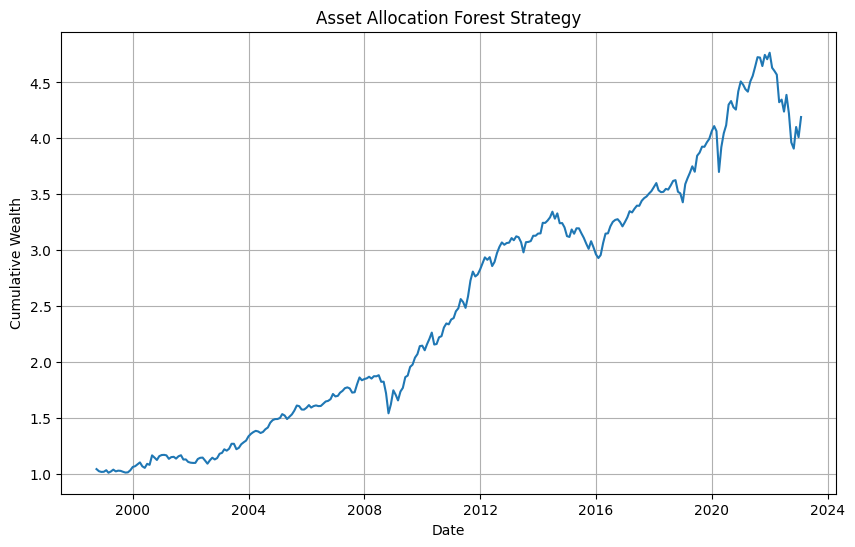

In [37]:
backtest['Wealth'] = (
    1 + backtest['Strategy_Return']
).cumprod()

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.plot(
    backtest['Date'],
    backtest['Wealth']
)

plt.title(
    'Asset Allocation Forest Strategy'
)

plt.ylabel(
    'Cumulative Wealth'
)

plt.xlabel(
    'Date'
)

plt.grid(True)

plt.show()

An out-of-sample backtest was conducted using an expanding-window framework. At each rebalancing date, the Asset Allocation Forest was estimated using all information available up to that point, and portfolio weights were applied to the subsequent month's asset returns. To reduce estimation variance, portfolio allocations were aggregated across multiple bootstrap trees

The resulting strategy generated an annualized return of 6.35% with an annualized volatility of 7.67%, producing a Sharpe Ratio of 0.83. The maximum drawdown over the evaluation period was 18.1%, indicating a moderate level of downside risk. Overall, the strategy delivered consistent long-term growth while maintaining relatively stable risk-adjusted performance

The cumulative wealth curve demonstrates that the Asset Allocation Forest was able to adapt to changing market conditions over time. Although the strategy experienced drawdowns during major market disruptions, including the Global Financial Crisis and the post-pandemic inflationary period, the overall trajectory remained positive throughout the out-of-sample period. These results suggest that macroeconomic state variables contain useful information for dynamic asset allocation decisions and that the Random Forest framework can successfully translate this information into economically meaningful portfolio allocations


In [38]:
# Equal-weight benchmark

equal_weights = np.repeat(
    1 / len(asset_cols),
    len(asset_cols)
)

benchmark_returns = []

for t in range(180, len(df) - 1):

    next_returns = (
        df.iloc[t + 1][asset_cols]
        .values
        .astype(float)
    )

    benchmark_return = np.dot(
        equal_weights,
        next_returns
    )

    benchmark_returns.append(
        benchmark_return
    )

benchmark_returns = pd.Series(
    benchmark_returns
)

In [39]:
benchmark_ann_return = (
    (1 + benchmark_returns.mean()) ** 12 - 1
)

benchmark_ann_vol = (
    benchmark_returns.std() * np.sqrt(12)
)

benchmark_sharpe = (
    benchmark_ann_return /
    benchmark_ann_vol
)

benchmark_wealth = (
    1 + benchmark_returns
).cumprod()

benchmark_mdd = (
    benchmark_wealth /
    benchmark_wealth.cummax() - 1
).min()

benchmark_perf = pd.DataFrame({
    'Metric': [
        'Annual Return',
        'Annual Volatility',
        'Sharpe Ratio',
        'Maximum Drawdown'
    ],
    'Benchmark': [
        benchmark_ann_return,
        benchmark_ann_vol,
        benchmark_sharpe,
        benchmark_mdd
    ]
})

print(
    benchmark_perf.round(4)
)

              Metric  Benchmark
0      Annual Return     0.0678
1  Annual Volatility     0.0814
2       Sharpe Ratio     0.8329
3   Maximum Drawdown    -0.2564


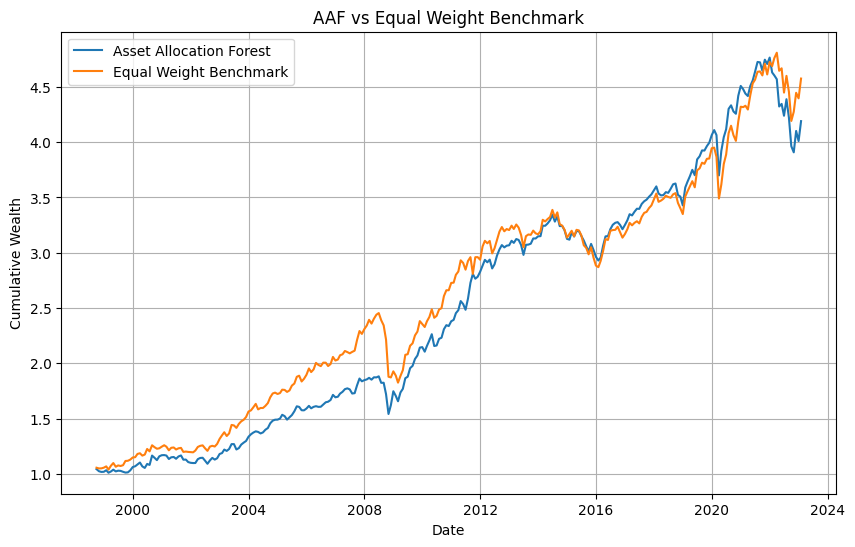

In [40]:
benchmark_df = pd.DataFrame({
    'Date': backtest['Date'],
    'Benchmark_Return': benchmark_returns.values
})

benchmark_df['Benchmark_Wealth'] = (
    1 + benchmark_df['Benchmark_Return']
).cumprod()

plt.figure(figsize=(10,6))

plt.plot(
    backtest['Date'],
    backtest['Wealth'],
    label='Asset Allocation Forest'
)

plt.plot(
    benchmark_df['Date'],
    benchmark_df['Benchmark_Wealth'],
    label='Equal Weight Benchmark'
)

plt.title(
    'AAF vs Equal Weight Benchmark'
)

plt.xlabel('Date')
plt.ylabel('Cumulative Wealth')

plt.legend()
plt.grid(True)

plt.show()

In [41]:
comparison = pd.DataFrame({
    'Metric': [
        'Annual Return',
        'Annual Volatility',
        'Sharpe Ratio',
        'Maximum Drawdown'
    ],
    'AAF': [
        annual_return,
        annual_volatility,
        sharpe_ratio,
        max_drawdown
    ],
    'Benchmark': [
        benchmark_ann_return,
        benchmark_ann_vol,
        benchmark_sharpe,
        benchmark_mdd
    ]
})

print(comparison.round(4))

              Metric     AAF  Benchmark
0      Annual Return  0.0635     0.0678
1  Annual Volatility  0.0767     0.0814
2       Sharpe Ratio  0.8289     0.8329
3   Maximum Drawdown -0.1810    -0.2564



The performance of the Asset Allocation Forest was evaluated against an equal-weight benchmark over the out-of-sample period from 1998 to 2023. The forest-based strategy achieved an annualized return of 6.35% and an annualized volatility of 7.67%, resulting in a Sharpe Ratio of 0.83. While the benchmark delivered a slightly higher return and a nearly identical Sharpe Ratio, the Asset Allocation Forest generated a substantially smaller maximum drawdown (-18.1% versus -25.6%).

The cumulative wealth comparison indicates that both strategies produced similar long-run outcomes. However, the forest-based approach generally exhibited smoother performance and improved downside protection during periods of market stress. These results suggest that conditioning portfolio allocations on macroeconomic state variables can help reduce portfolio risk, although the simplified implementation used in this assignment does not generate a substantial improvement in risk-adjusted returns relative to the benchmark.

**It is important to note that the implemented forest consisted of only three bootstrap trees. This choice was made to maintain computational feasibility during the out-of-sample backtest, as each tree requires repeated portfolio optimization across multiple candidate splits and expanding estimation windows. In a full-scale implementation, a substantially larger number of trees would typically be employed. A larger forest would be expected to reduce estimation variance, improve allocation stability, and potentially enhance out-of-sample performance. Therefore, the results reported here should be viewed as a proof of concept rather than the maximum achievable performance of the Asset Allocation Forest framework**

Overall, the exercise demonstrates how Random Forest methods can be adapted to dynamic asset allocation problems and how machine learning techniques can incorporate economic state information into portfolio construction decisions


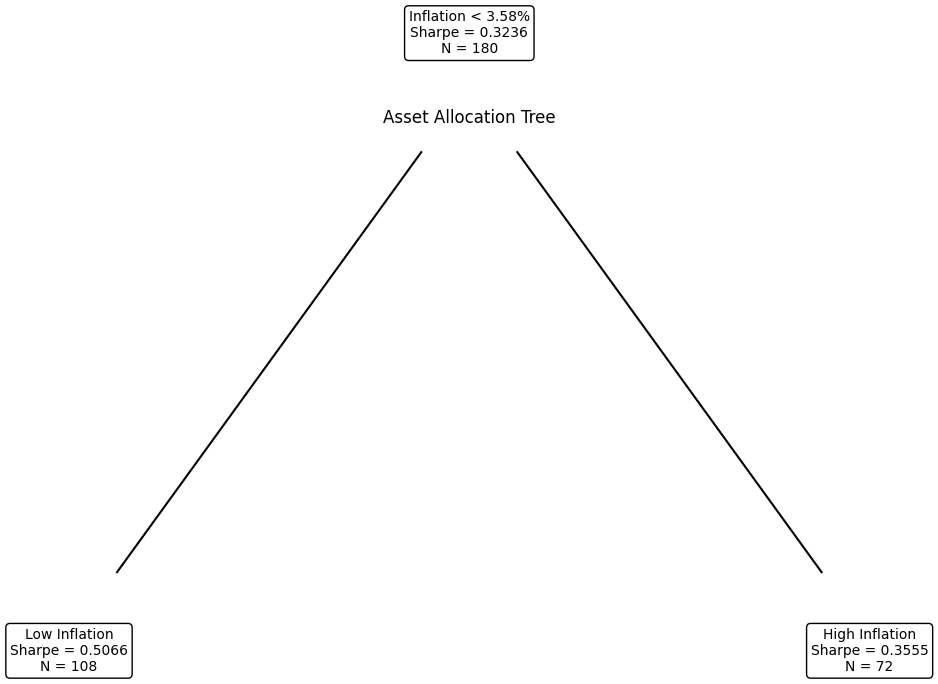

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Root
plt.text(
    0.5, 0.8,
    'Inflation < 3.58%\nSharpe = 0.3236\nN = 180',
    ha='center',
    bbox=dict(boxstyle='round', fill=False)
)

# Left node
plt.text(
    0.25, 0.3,
    'Low Inflation\nSharpe = 0.5066\nN = 108',
    ha='center',
    bbox=dict(boxstyle='round', fill=False)
)

# Right node
plt.text(
    0.75, 0.3,
    'High Inflation\nSharpe = 0.3555\nN = 72',
    ha='center',
    bbox=dict(boxstyle='round', fill=False)
)

# Connections
plt.plot([0.47, 0.28], [0.72, 0.38], 'k-')
plt.plot([0.53, 0.72], [0.72, 0.38], 'k-')

plt.title('Asset Allocation Tree')
plt.axis('off')

plt.show()